In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from xgboost import XGBClassifier
import joblib

In [ ]:
df = pd.read_csv("heart_2020_cleaned.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  object 
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  object 
 3   AlcoholDrinking   319795 non-null  object 
 4   Stroke            319795 non-null  object 
 5   PhysicalHealth    319795 non-null  float64
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       319795 non-null  object 
 8   Sex               319795 non-null  object 
 9   AgeCategory       319795 non-null  object 
 10  Race              319795 non-null  object 
 11  Diabetic          319795 non-null  object 
 12  PhysicalActivity  319795 non-null  object 
 13  GenHealth         319795 non-null  object 
 14  SleepTime         319795 non-null  float64
 15  Asthma            319795 non-null  object 
 16  KidneyDisease     31

In [ ]:
np.random.seed(42)

df["Pollution_PM25"] = np.random.uniform(5, 50, size=len(df))
df["Walkability"] = np.random.uniform(0, 1, size=len(df))
df["FoodDesertIndex"] = np.random.uniform(0, 1, size=len(df))
features = [
    "Smoking",
    "Diabetic",
    "PhysicalActivity",
    "AlcoholDrinking",
    "SleepTime",
    "BMI",
    "MentalHealth",
    "Pollution_PM25",
    "Walkability",
    "FoodDesertIndex"
]

df_model = df[features + ["HeartDisease"]]


In [ ]:
df_model["HeartDisease"] = df_model["HeartDisease"].map({"Yes": 1, "No": 0})
""

C:\Users\munja\AppData\Local\Temp\ipykernel_32164\913657352.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model["HeartDisease"] = df_model["HeartDisease"].map({"Yes": 1, "No": 0})


''

In [ ]:
df_model.head()

,Smoking,Diabetic,PhysicalActivity,AlcoholDrinking,SleepTime,BMI,MentalHealth,Pollution_PM25,Walkability,FoodDesertIndex,HeartDisease
0,Yes,Yes,Yes,No,5.0,16.60,30.0,21.854305,0.942806,0.783601,0
1,No,No,Yes,No,7.0,20.34,0.0,47.782144,0.808649,0.726155,0
2,Yes,Yes,Yes,No,8.0,26.58,30.0,37.939727,0.671400,0.463550,0
3,No,No,No,No,6.0,24.21,0.0,31.939632,0.576435,0.602212,0
4,No,No,Yes,No,8.0,23.71,0.0,12.020839,0.120157,0.905223,0


In [ ]:
categorical_cols = df_model.select_dtypes(include=['object']).columns

le = LabelEncoder()
for col in categorical_cols:
    df_model[col] = le.fit_transform(df_model[col])

C:\Users\munja\AppData\Local\Temp\ipykernel_32164\572943352.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model[col] = le.fit_transform(df_model[col])
C:\Users\munja\AppData\Local\Temp\ipykernel_32164\572943352.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model[col] = le.fit_transform(df_model[col])
C:\Users\munja\AppData\Local\Temp\ipykernel_32164\572943352.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_ind

In [ ]:
df_model = df_model.apply(pd.to_numeric)  # force numeric
df_model = df_model.fillna(0)             # replace any unexpected NaNs with 0


In [ ]:
X = df_model[features]
y = df_model["HeartDisease"]
print(X.columns)
print(y.value_counts())


Index(['Smoking', 'Diabetic', 'PhysicalActivity', 'AlcoholDrinking',
       'SleepTime', 'BMI', 'MentalHealth', 'Pollution_PM25', 'Walkability',
       'FoodDesertIndex'],
      dtype='object')
HeartDisease
0    292422
1     27373
Name: count, dtype: int64


In [ ]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE
smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2,
    random_state=42
)
print("After SMOTE:")
print(y_resampled.value_counts())

After SMOTE:
HeartDisease
0    292422
1    292422
Name: count, dtype: int64


In [ ]:
X_train = X_train.apply(pd.to_numeric)
X_test = X_test.apply(pd.to_numeric)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    eval_metric="logloss",
    random_state=42
)
xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [ ]:
print(y_resampled.value_counts())

HeartDisease
0    292422
1    292422
Name: count, dtype: int64


In [ ]:
print("Logistic Regression:", accuracy_score(y_test, lr.predict(X_test_scaled)))
print("Random Forest:", accuracy_score(y_test, rf.predict(X_test)))
print("XGBoost:", accuracy_score(y_test, xgb.predict(X_test)))

Logistic Regression: 0.6521300515521207
Random Forest: 0.8775744000547153
XGBoost: 0.7641939317254999


In [ ]:
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]
rf_prob = rf.predict_proba(X_test)[:, 1]
xgb_prob = xgb.predict_proba(X_test)[:, 1]

# Weighted average
hybrid_prob = 0.2 * lr_prob + 0.3 * rf_prob + 0.5 * xgb_prob

# Convert to class
hybrid_pred = (hybrid_prob >= 0.5).astype(int)

print("Hybrid Accuracy:", accuracy_score(y_test, hybrid_pred))
print("Hybrid ROC-AUC:", roc_auc_score(y_test, hybrid_prob))
print("\nClassification Report:\n")
print(classification_report(y_test, hybrid_pred))


Hybrid Accuracy: 0.8173020201933846
Hybrid ROC-AUC: 0.9062340234949062

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.83      0.82     58485
           1       0.83      0.80      0.81     58484

    accuracy                           0.82    116969
   macro avg       0.82      0.82      0.82    116969
weighted avg       0.82      0.82      0.82    116969



In [ ]:
print("\nLR Predictions:\n", lr_prob[:5])
print("\nRF Predictions:\n", rf_prob[:5])
print("\nXGB Predictions:\n", xgb_prob[:5])


LR Predictions:
 [0.34535597 0.84113707 0.37564639 0.5832633  0.34276748]

RF Predictions:
 [0.95  0.55  0.605 0.085 0.46 ]

XGB Predictions:
 [0.9154319  0.7008676  0.6565674  0.21769707 0.30735853]


In [ ]:
joblib.dump(lr, "lr_cardio_sdoh.pkl")
joblib.dump(rf, "rf_cardio_sdoh.pkl")
joblib.dump(xgb, "xgb_cardio_sdoh.pkl")
joblib.dump(scaler, "scaler_cardio_sdoh.pkl")

['scaler_cardio_sdoh.pkl']

In [ ]:
import joblib

heart_bundle = {
    "lr": lr,
    "rf": rf,
    "xgb": xgb,
    "scaler": scaler,
    "features": X.columns.tolist()
}

joblib.dump(heart_bundle, "models/heart.pkl")

['models/heart.pkl']

In [ ]:
def simulate_user_risk(user_data):
    
    user_df = pd.DataFrame([user_data])
    
    # Scale for LR
    user_scaled = scaler.transform(user_df)

    # Base risk
    base_lr = lr.predict_proba(user_scaled)[:, 1]
    base_rf = rf.predict_proba(user_df)[:, 1]
    base_xgb = xgb.predict_proba(user_df)[:, 1]
    
    base_risk = 0.3*base_lr + 0.3*base_rf + 0.4*base_xgb
    base_risk = base_risk[0]

    results = []

    scenarios = {
        "Stop Smoking": {"Smoking": 0},
        "Increase Physical Activity": {"PhysicalActivity": 1},
        "Better Environment": {
            "Pollution_PM25": 10,
            "Walkability": 0.9,
            "FoodDesertIndex": 0.2
        }
    }

    for name, changes in scenarios.items():
        twin = user_df.copy()
        for col, val in changes.items():
            twin[col] = val

        twin_scaled = scaler.transform(twin)

        twin_lr = lr.predict_proba(twin_scaled)[:, 1]
        twin_rf = rf.predict_proba(twin)[:, 1]
        twin_xgb = xgb.predict_proba(twin)[:, 1]

        twin_risk = 0.3*twin_lr + 0.3*twin_rf + 0.4*twin_xgb
        results.append((name, twin_risk[0]))

    return base_risk, results


In [ ]:
user_data = {
    "Smoking": 1,
    "Diabetic": 1,
    "PhysicalActivity": 0,
    "AlcoholDrinking": 1,
    "SleepTime": 5,
    "BMI": 30,
    "MentalHealth": 2,
    "Pollution_PM25": 35,
    "Walkability": 0.3,
    "FoodDesertIndex": 0.8
}


In [ ]:
base_risk, scenario_results = simulate_user_risk(user_data)

print(f"\nBase CVD Risk: {base_risk:.2%}\n")

for name, risk in scenario_results:
    reduction = (base_risk - risk) / base_risk * 100
    print(f"{name} → {risk:.2%}  |  Risk Reduction: {reduction:.2f}%")



Base CVD Risk: 23.59%

Stop Smoking → 18.26%  |  Risk Reduction: 22.61%
Increase Physical Activity → 8.05%  |  Risk Reduction: 65.88%
Better Environment → 25.21%  |  Risk Reduction: -6.85%


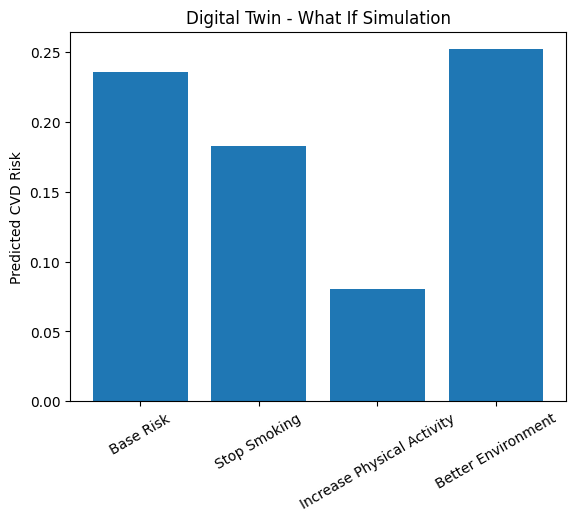

In [ ]:
import matplotlib.pyplot as plt

labels = ["Base Risk"] + [name for name, _ in scenario_results]
values = [base_risk] + [risk for _, risk in scenario_results]

plt.figure()
plt.bar(labels, values)
plt.ylabel("Predicted CVD Risk")
plt.title("Digital Twin - What If Simulation")
plt.xticks(rotation=30)
plt.show()
